# Second order accessibility

This notebook presents an initial approach to the concept of "second order accessibility", which involves measuring accessibility to services not only considering where people live, but also where people work or study. Using an accessibility function that considers supply and demand, the aim is to examine how accessibility changes when considering not only the population living in each area, but also the population working there.

The city of Santiago, Chile will be used as the study area, considering four types of services that are commonly accessed both from one's home or from one's workplace:

- Pharmacies.
- Supermarkets or convenience stores.
- Banks.
- Health centers (either private or public).

**IMPORTANT**: to run this notebook, the coordinates of workplace locations in
Chile is required. The data (from Chile's Internal Revenue Service, SII)
originally has locations as addresses (in plain text), so a geocoding process
is required, which is not done by default when running
[`make_dataset.py`](../../scripts/make_dataset.py).

To do this geocoding, a local Nominatim database must be enabled, and loaded
with the PBF file `Chile.osm.pbf` (containing address coordinates for the
entire country). Instructions on how to install Nominatim are found
[here](https://nominatim.org/release-docs/latest/admin/Installation/), while
instructions on how to import data from a PBF file can be found
[here](https://nominatim.org/release-docs/latest/admin/Import/).

Once the database is enabled, the path to the database installation must be
added to a `.env` file under the name `NOMINATIM_PATH` (this is, the .env file
must have a line that reads `NOMINATIM_PATH=<path to installation>`). Lastly,
you can run the command `uv sync --extra nominatim` to install the necessary
dependencies to call the database, and then run the command `uv run
scripts/make_dataset.py trabajos` to download and geocode the data.

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import datetime
from pathlib import Path

import geopandas as gpd
import pandas as pd
import numpy as np
from tqdm.auto import tqdm

from libpysal import weights
import mapclassify
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec

import xmin
from xmin.dataset import extract_osm_subset
from xmin.indices import EnhancedTwoStepFca

tqdm.pandas()

In [3]:
RAW_DATA_PATH = Path("../../data/raw")  # non-processed data
PRE_DATA_PATH = Path("../../data/processed")  # pre-processed data
xmin.config.quackosm_working_directory = Path("../../data/interim/quackosm")

In [4]:
OSM_CHILE_PATH = RAW_DATA_PATH / "osm" / "Chile.osm.pbf"

CENSUS_PATH = PRE_DATA_PATH / "censo" / "Cartografia.gpkg"
AMENITY_HEALTH_PATH = PRE_DATA_PATH / "amenities" / "salud.gpkg"
WORKPLACES_PATH = PRE_DATA_PATH / "trabajos" / "trabajos.gpkg"
OSM_SANTIAGO_PATH = PRE_DATA_PATH / "osm" / "Santiago.osm.pbf"

## Origins, destinations and TTMs

In [6]:
urban_boundaries_full = gpd.read_file(
    CENSUS_PATH,
    layer="Limite_Urbano_CPV24",
)

# we only filter boundaries corresponding to Valparaíso
urban_boundaries = urban_boundaries_full[
    (urban_boundaries_full["LOCALIDAD"] == "GRAN SANTIAGO")
]

# we get the convex hull to extract POIs and road network
boundaries_hull = urban_boundaries.union_all().convex_hull

In [7]:
city_blocks = gpd.read_file(
    CENSUS_PATH,
    layer="Manzanas_CPV24",
    mask=urban_boundaries.union_all(),
    use_arrow=True
)

Initially, we create the `Origins` object considering no working population
(only living population); we will then add the working population and compare
its effects.

In [8]:
origins = xmin.Origins.create_grid(
    regions=urban_boundaries,
    h3_resolution=9,
    population_gdf=city_blocks.rename(columns={"n_per": "population"}),
)

In [9]:
if not OSM_SANTIAGO_PATH.exists():
    extract_osm_subset(
        OSM_CHILE_PATH,
        OSM_SANTIAGO_PATH,
        bounds=boundaries_hull
    )

In [10]:
pharmacies = xmin.Amenity.from_osm(
    name="pharmacies",
    osm_path=OSM_SANTIAGO_PATH,
    osm_filter={"amenity": ["pharmacy"]},
    keep_all_tags=["name"]
)

In [11]:
supermarkets = xmin.Amenity.from_osm(
    name="supermarkets",
    osm_path=OSM_SANTIAGO_PATH,
    osm_filter={"shop": ["supermarket", "convenience"]},
    keep_all_tags=["name"]
)

In [12]:
banks = xmin.Amenity.from_osm(
    name="banks",
    osm_path=OSM_SANTIAGO_PATH,
    osm_filter={"amenity": "bank"},
    keep_all_tags=["name"]
)

In [13]:
health_gdf = gpd.read_file(AMENITY_HEALTH_PATH, mask=boundaries_hull)

health = xmin.Amenity(
    name="health",
    amenity_gdf=health_gdf[health_gdf["TIPO"].isin(
        ["Centro de Salud Privado", "Centro de Salud Familiar (CESFAM)"]
    )]
)

In [14]:
ttms = xmin.TravelTimeMatrices.compute(
    origins=origins,
    amenities=[pharmacies, supermarkets, banks, health],
    gtfs_paths=[],
    osm_path=OSM_SANTIAGO_PATH,
    snap_to_network=True,
    max_time=datetime.timedelta(minutes=30),
    transport_modes=["WALK"],
)

Calculando tiempos de viaje desde cada origen...


  0%|          | 0/9025 [00:00<?, ?it/s]

In [15]:
workplaces = gpd.read_file(WORKPLACES_PATH)

## Population calculation

The working population does not necessarily have the same demand for services
as those who live in the area; thus, to the living population we will add the
working population weighted by a parameter $\alpha$, between 0 and 1. If
$\alpha=0$, then the working population has no impact. If $\alpha=1$, then they
demand the services to the same extent as the living population, and
intermediate values exhibit intermediate behaviors.

In [16]:
population_grid = origins.h3_grid.set_index("id").rename(
    columns={"population": "pop_living"}
)

population_grid["pop_working"] = workplaces.sjoin(
    population_grid, how="inner", predicate="within"
).groupby("id_right")["weight"].sum()
population_grid["pop_working"] = population_grid["pop_working"].fillna(0)

# reset index and reorder columns
population_grid = population_grid[
    ["pop_living", "pop_working", "geometry"]
].reset_index()

In [17]:
origins_work_25 = xmin.Origins(
    origins.regions,
    origins.h3_resolution,
    population_grid.assign(
        population=(
            population_grid["pop_living"]
            + 0.25 * population_grid["pop_working"]
        )
    )
)

origins_work_50 = xmin.Origins(
    origins.regions,
    origins.h3_resolution,
    population_grid.assign(
        population=(
            population_grid["pop_living"]
            + 0.50 * population_grid["pop_working"]
        )
    )
)

origins_work_100 = xmin.Origins(
    origins.regions,
    origins.h3_resolution,
    population_grid.assign(
        population=(
            population_grid["pop_living"]
            + population_grid["pop_working"]
        )
    )
)

In [18]:
ttms_work_25 = xmin.TravelTimeMatrices(
    origins_work_25,
    ttms.amenities.values(),
    ttms.matrices
)

ttms_work_50 = xmin.TravelTimeMatrices(
    origins_work_50,
    ttms.amenities.values(),
    ttms.matrices
)

ttms_work_100 = xmin.TravelTimeMatrices(
    origins_work_100,
    ttms.amenities.values(),
    ttms.matrices
)

## Accessibility calculations

We calculate accessibility using E2SFCA, thus considering supply and demand.
The different amenity types were assigned weights according to the frequency
with which they are used.

In [24]:
index = EnhancedTwoStepFca(
    catchment_areas=[
        (0, 10, 1.00),
        (10, 20, 0.42),
        (20, 30, 0.03),
    ],
    desired_ratio=3_000,
)

acc_weights = {
    "pharmacies": 1,
    "supermarkets": 1,
    "banks": 0.5,
    "health": 0.5,
}

In [25]:
acc_work_0 = xmin.AccessibilityRatings.compute(ttms, index, acc_weights)
acc_work_25 = xmin.AccessibilityRatings.compute(ttms_work_25, index, acc_weights)
acc_work_50 = xmin.AccessibilityRatings.compute(ttms_work_50, index, acc_weights)
acc_work_100 = xmin.AccessibilityRatings.compute(ttms_work_100, index, acc_weights)

Calculando índices para cada necesidad...


  0%|          | 0/4 [00:00<?, ?it/s]

Calculando índices para cada necesidad...


  0%|          | 0/4 [00:00<?, ?it/s]

Calculando índices para cada necesidad...


  0%|          | 0/4 [00:00<?, ?it/s]

Calculando índices para cada necesidad...


  0%|          | 0/4 [00:00<?, ?it/s]

## Visualizations

### Comparison between $\alpha$ values

Observing how accessibility changes as $\alpha$ (the weight given to the
working population) increases, we can see that all areas of the city suffer a
reduction in their scores; this is expected, as demand grows while supply stays
constant. However, it is interesting to note which areas decrease the most.

Visualizing the difference in accessibility between $\alpha=0$ and
$\alpha=0.5$, we can see the areas with the greatest score loss include Ciudad
Empresarial (in Huechuraba, in the northern part of Santiago) and the
industrial area in Quilicura (northwestern part of Santiago). These are places
that have enough services for the people living there (who tend to be few), but
not for those who work there. This can be contrasted with the reduction in
accessibility in areas like the center of Santiago, or Av. Providencia in the
neighboring commune of Providencia, which have a more robust range of services
capable of covering the needs of not only the living population, but also those
who travel there for work purposes. Thus, the accessibility scores in these
areas are not reduced when including the working population.

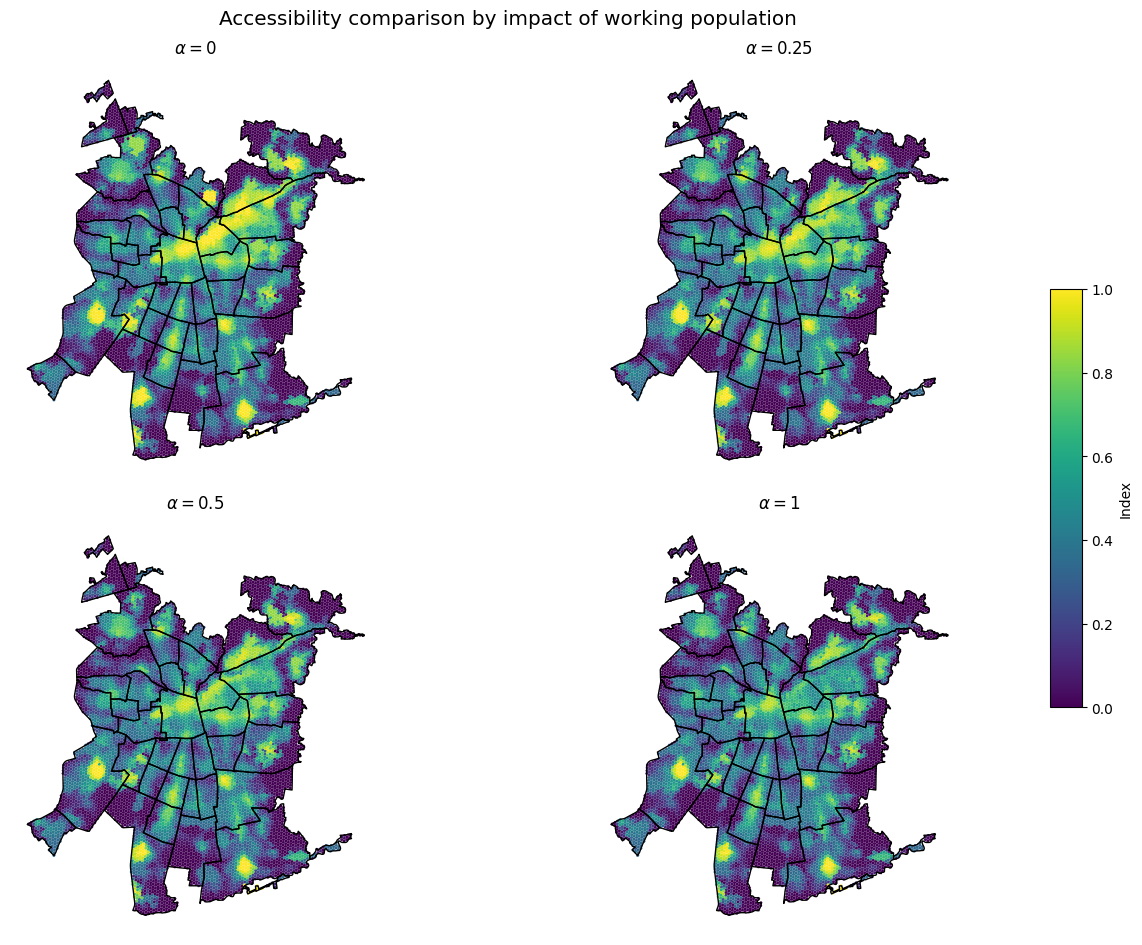

In [31]:
fig = plt.figure(figsize=(2 * 6.4, 2 * 4.8))
gs = GridSpec(4, 3, figure=fig, width_ratios=[100, 100, 5])
ax_0 = fig.add_subplot(gs[0:2, 0])
ax_25 = fig.add_subplot(gs[0:2, 1])
ax_50 = fig.add_subplot(gs[2:4, 0])
ax_100 = fig.add_subplot(gs[2:4, 1])
ax_cb = fig.add_subplot(gs[1:3, 2])

for ax, acc, name in zip(
    (ax_0, ax_25, ax_50, ax_100),
    (acc_work_0, acc_work_25, acc_work_50, acc_work_100),
    (r"$\alpha=0$", r"$\alpha=0.25$", r"$\alpha=0.5$", r"$\alpha=1$")
):
    acc.visualize.choropleth("total", ax=ax)
    ax.set_axis_off()
    ax.set_title(name)

cbar = plt.cm.ScalarMappable(cmap="viridis")
axCbar = fig.colorbar(cbar, cax=ax_cb)
axCbar.set_label(f"Index")

fig.suptitle(
    "Accessibility comparison by impact of working population",
    fontsize="x-large"
)

plt.tight_layout()

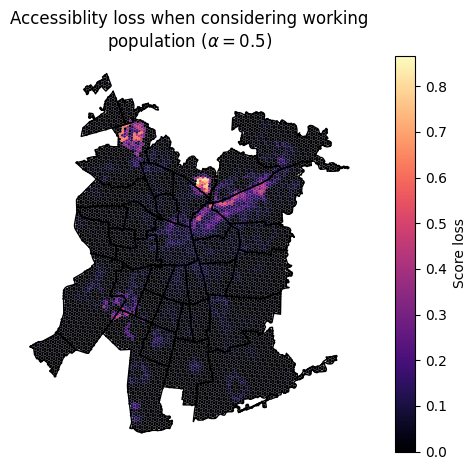

In [27]:
ax = acc_work_50.visualize.choropleth(
    acc_work_0.gdf["total"] - acc_work_50.gdf["total"],
    legend=True,
    legend_kwds={"label": "Score loss"},
    cmap="magma"
)
ax.set_axis_off()
ax.set_title(
    "Accessiblity loss when considering working\n"
    "population ($\\alpha=0.5$)"
)

plt.tight_layout()

### Relationship between accessibility and working population

The following visualization shows the relationship between accessibility
considering the working population ($\alpha=0.5$) and the working population in
each cell, through a bivariate choropleth map.

Firstly, the working population was smoothed using a kernel function, to reduce
noise in the visualization and understanding that, more than the working
population in each specific cell, we are interested in the rough number of
workers who might want to access nearby services. This means that we not only
care about the workers in the cell itself, but also those in nearby cells.

Analyzing the relationship via the bivariate choropleth map, and concentrating
on areas with a high working population (blue hues), a clear difference is
observed between areas that can be considered "centers" of the city, and areas
that are simply employment districts. The city centers not only concentrate a
high amount of workers, but also a high quantity of services, capable of
satisfying both the living and working population. In the city of Santiago,
these conditions are met by the points colores in a darker shade of blue,
concentrated on the historic center of Santiago, as well as Av. Providencia and
Av. Apoquindo. These are places where people go for work, but where they can
also access services and run various errands.

On the other hand, employment districts attract a great number of workers, but
lack the services to satisfy their population (living and working). In
Santiago, the area that most clearly satisfies these conditions is Ciudad
Empresarial in Huechuraba (colored in light blue/cyan). Places like this
attract many people for work purposes, but in order to turn themselves into
proper "city centers" they also need to be able to offer services for those who
live and work there.

In [28]:
# weights for computing smoothing (kernel)
w = weights.Kernel.from_dataframe(population_grid, diagonal=True)
w.transform = "r"

# smoothed working population
population_grid["smooth_working"] = weights.spatial_lag.lag_spatial(
    w, population_grid['pop_working']
)

/home/clau/x-minute-chile/.venv/lib/python3.12/site-packages/libpysal/weights/distance.py:569: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  W.__init__(self, neighbors, weights, ids, **kwargs)


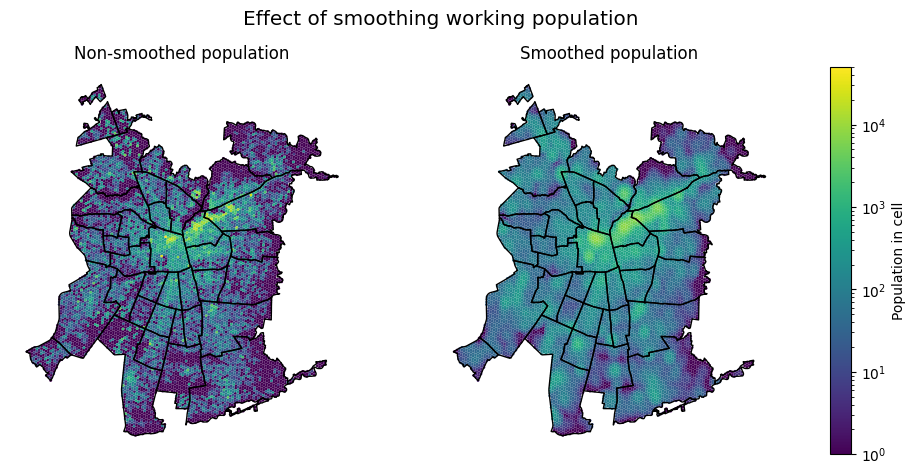

In [29]:
fig = plt.figure(figsize=(1.5 * 6.4, 4.8))
gs = GridSpec(1, 3, figure=fig, width_ratios=[100, 100, 5])
ax_normal = fig.add_subplot(gs[0, 0])
ax_smooth = fig.add_subplot(gs[0, 1])
ax_cb = fig.add_subplot(gs[0, 2])

norm = mcolors.LogNorm(vmin=1, vmax=50_000, clip=True)

for ax, column, name in zip(
    (ax_normal, ax_smooth),
    ("pop_working", "smooth_working"),
    ("Non-smoothed population", "Smoothed population")
):
    population_grid.plot(column, norm=norm, ax=ax)
    origins.regions.plot(facecolor="none", edgecolor="black", ax=ax)
    ax.set_axis_off()
    ax.set_title(name)

cbar = plt.cm.ScalarMappable(norm=norm, cmap="viridis")
axCbar = fig.colorbar(cbar, cax=ax_cb)
axCbar.set_label(f"Population in cell")

fig.suptitle(
    "Effect of smoothing working population",
    fontsize="x-large"
)

plt.tight_layout()

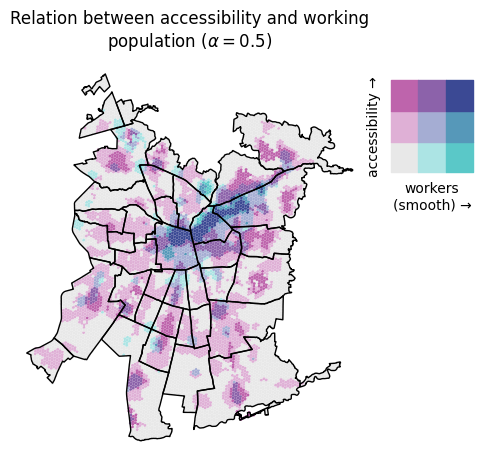

In [30]:
ax = acc_work_50.visualize.bivariate_choropleth(
    acc_work_50.gdf["total"].rename("accessibility"),
    population_grid.set_index("id")["smooth_working"].rename(
        "workers\n(smooth)"
    ),
    classifier=(
        mapclassify.EqualInterval,
        lambda y, _: mapclassify.UserDefined(y, [225, 1000, 100_000])
    ),
    legend=True,
)

ax.set_axis_off()
ax.set_title(
    "Relation between accessibility and working\npopulation ($\\alpha=0.5$)"
)

plt.tight_layout()